In [1]:
import sys

sys.path.append("..")

from common.metrics import metrics
from common.preprocessing import preprocessing_rg3
from common.train_test_split import split_data
from common.model_composition import model_composition

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [56]:
import pandas as pd
import numpy as np

rg3_raw = pd.read_csv(r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3_되돌림.csv")

rg3 = rg3_raw.copy()

print("Shape:", rg3.shape)

display(rg3.head())

Shape: (1182, 29)


,original_index,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,TimeStamp,PART_NAME,RH_LH
0,1211,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,...,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042,2020-10-21 00:57:37,"RG3 MOLD'G W/SHLD, LH",LH
1,1212,0,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,...,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042,2020-10-21 00:57:37,"RG3 MOLD'G W/SHLD, RH",RH
2,1213,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,...,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042,2020-10-21 00:56:34,"RG3 MOLD'G W/SHLD, LH",LH
3,1214,0,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,...,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042,2020-10-21 00:56:34,"RG3 MOLD'G W/SHLD, RH",RH
4,1215,0,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,...,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042,2020-10-21 00:55:34,"RG3 MOLD'G W/SHLD, LH",LH


# 1. EDA

# 1. 1차 EDA

데이터 크기 / 컬럼 구조 확인   
결측치 / 중복 확인   
Target 분포 확인   
LH/RH 구조 확인   
PART_NAME과 RH_LH 중복 정보 확인   
동일 TimeStamp의 LH/RH 공정값 동일 여부 확인   
동일 X / 다른 Target 문제 확인   
분석 단위를 1,182행 → 591 Cycle로 재정의   
Standard Scaling 여부 확인   
상수 / 저고유값 변수 확인   
변수 간 상관관계 확인      
Target과 단순 상관관계 확인   
정상/불량 평균 차이 확인    
단변량 ROC-AUC screening   
|z|>3 극단값과 불량 관계 확인   
생산 시간 간격 확인   
7개 Session 구조 확인   

### 데이터 컬럼 구조 확인

In [57]:
display(
    pd.DataFrame({
        "dtype": rg3.dtypes,
        "nunique": rg3.nunique(dropna=False),
        "missing": rg3.isna().sum()
    })
)

,dtype,nunique,missing
original_index,int64,1182,0
PassOrFail,int64,2,0
Injection_Time,float64,3,0
Filling_Time,float64,2,0
Plasticizing_Time,float64,27,0
Cycle_Time,float64,10,0
Clamp_Close_Time,float64,3,0
Cushion_Position,float64,7,0
Plasticizing_Position,float64,8,0
Clamp_Open_Position,float64,1,0


In [58]:
display(
    pd.DataFrame({
        "dtype": rg3.dtypes,
        "nunique": rg3.nunique(dropna=False),
        "missing": rg3.isna().sum()
    })
)

,dtype,nunique,missing
original_index,int64,1182,0
PassOrFail,int64,2,0
Injection_Time,float64,3,0
Filling_Time,float64,2,0
Plasticizing_Time,float64,27,0
Cycle_Time,float64,10,0
Clamp_Close_Time,float64,3,0
Cushion_Position,float64,7,0
Plasticizing_Position,float64,8,0
Clamp_Open_Position,float64,1,0


### 변수 역할 분리

In [59]:
TARGET = "PassOrFail"

ID_COLS = [
    "original_index"
]

TIME_COLS = [
    "TimeStamp"
]

CATEGORY_COLS = [
    "PART_NAME",
    "RH_LH"
]

PROCESS_COLS = [
    col for col in rg3.columns
    if col not in (
        [TARGET]
        + ID_COLS
        + TIME_COLS
        + CATEGORY_COLS
    )
]

print("공정 변수 수:", len(PROCESS_COLS))

PROCESS_COLS

공정 변수 수: 24


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

### 데이터 품질 확인

In [60]:
missing = (
    rg3.isna()
       .sum()
       .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

print(
    "전체 결측치:",
    rg3.isna().sum().sum()
)

Series([], dtype: int64)

전체 결측치: 0


In [61]:
print(
    "완전 중복 행:",
    rg3.duplicated().sum()
)

완전 중복 행: 0


### original index 확인

In [62]:
print(
    "최소:",
    rg3["original_index"].min()
)

print(
    "최대:",
    rg3["original_index"].max()
)

print(
    "고유값:",
    rg3["original_index"].nunique()
)

print(
    "중복:",
    rg3["original_index"].duplicated().sum()
)

최소: 1211
최대: 2392
고유값: 1182
중복: 0


### target 분포 확인

In [63]:
target_count = (
    rg3[TARGET]
    .value_counts()
    .sort_index()
)

target_ratio = (
    rg3[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_count,
    "Ratio(%)": target_ratio
})

display(target_summary)

,Count,Ratio(%)
PassOrFail,,
0,1157,97.884941
1,25,2.115059


### partname rh lh 구조

In [64]:
print("[RH_LH]")

display(
    rg3["RH_LH"]
    .value_counts()
    .to_frame("Count")
)

print("\n[PART_NAME]")

display(
    rg3["PART_NAME"]
    .value_counts()
    .to_frame("Count")
)

[RH_LH]


,Count
RH_LH,
LH,591
RH,591



[PART_NAME]


,Count
PART_NAME,
"RG3 MOLD'G W/SHLD, LH",591
"RG3 MOLD'G W/SHLD, RH",591


### side 별 target 확인

In [65]:
side_target = pd.crosstab(
    rg3["RH_LH"],
    rg3[TARGET],
    margins=True
)

display(side_target)

PassOrFail,0,1,All
RH_LH,,,
LH,591,0,591
RH,566,25,591
All,1157,25,1182


In [66]:
side_target_summary = (
    rg3.groupby("RH_LH")[TARGET]
    .agg(
        Total="count",
        Defect="sum",
        Defect_Rate="mean"
    )
)

side_target_summary[
    "Defect_Rate"
] *= 100

display(side_target_summary)

,Total,Defect,Defect_Rate
RH_LH,,,
LH,591,0,0.000000
RH,591,25,4.230118


### timestamp 변환

In [67]:
rg3["TimeStamp"] = pd.to_datetime(
    rg3["TimeStamp"]
)

print(
    "시작:",
    rg3["TimeStamp"].min()
)

print(
    "종료:",
    rg3["TimeStamp"].max()
)

print(
    "고유 TimeStamp:",
    rg3["TimeStamp"].nunique()
)

시작: 2020-10-21 00:16:26
종료: 2020-10-23 07:46:03
고유 TimeStamp: 591


### timestamp 하나당 몇 행인지 확인

In [68]:
timestamp_count = (
    rg3.groupby("TimeStamp")
       .size()
)

display(
    timestamp_count
    .value_counts()
    .sort_index()
)

2    591
Name: count, dtype: int64

### 모든 cycle에 rh lh가 하나씩 있는지 확인

In [69]:
side_per_cycle = (
    rg3.groupby("TimeStamp")["RH_LH"]
       .nunique()
)

print(
    "LH/RH 둘 다 존재하는 Cycle:",
    (side_per_cycle == 2).sum()
)

print(
    "전체 Cycle:",
    len(side_per_cycle)
)

LH/RH 둘 다 존재하는 Cycle: 591
전체 Cycle: 591


### 같은 cycle의 lh rh 공정값 비교

In [70]:
pair_nunique = (
    rg3.groupby("TimeStamp")[
        PROCESS_COLS
    ]
    .nunique(dropna=False)
)

same_process_cycle = (
    pair_nunique
    .max(axis=1)
    .eq(1)
)

print(
    "LH/RH 공정값이 모두 동일한 Cycle:",
    same_process_cycle.sum()
)

print(
    "전체 Cycle:",
    len(same_process_cycle)
)

LH/RH 공정값이 모두 동일한 Cycle: 591
전체 Cycle: 591


### 같은 공정값인데 target이 다른 경우

In [71]:
same_x_target_count = (
    rg3.groupby(
        PROCESS_COLS,
        dropna=False
    )[TARGET]
    .nunique()
)

print(
    "고유 공정조건 수:",
    len(same_x_target_count)
)

print(
    "동일 X에 서로 다른 Target이 존재하는 경우:",
    (same_x_target_count > 1).sum()
)

고유 공정조건 수: 591
동일 X에 서로 다른 Target이 존재하는 경우: 25


### LH RH Target 조합 확인

In [72]:
target_pair = (
    rg3.pivot(
        index="TimeStamp",
        columns="RH_LH",
        values=TARGET
    )
)

display(
    target_pair
    .value_counts()
    .to_frame("Cycle_Count")
)

Cycle_Count
LH RH             
0  0           566
   1            25

### cycle 데이터 생성

In [73]:
rg3_cycle = (
    rg3.sort_values(
        "TimeStamp"
    )
    .drop_duplicates(
        subset="TimeStamp",
        keep="first"
    )
    [
        ["TimeStamp"]
        + PROCESS_COLS
    ]
    .copy()
)

In [74]:
cycle_target = (
    rg3.groupby("TimeStamp")[TARGET]
       .max()
       .rename("Cycle_Defect")
)

In [75]:
rg3_cycle = (
    rg3_cycle
    .merge(
        cycle_target,
        on="TimeStamp",
        how="left"
    )
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

In [76]:
print(
    "Cycle 데이터:",
    rg3_cycle.shape
)

display(
    rg3_cycle["Cycle_Defect"]
    .value_counts()
    .to_frame("Count")
)

Cycle 데이터: (591, 26)


,Count
Cycle_Defect,
0,566
1,25


### standard scaling 여부 확인

In [77]:
scale_check = pd.DataFrame({
    "mean": rg3[PROCESS_COLS].mean(),
    "std": rg3[PROCESS_COLS].std(ddof=0),
    "min": rg3[PROCESS_COLS].min(),
    "max": rg3[PROCESS_COLS].max(),
    "nunique": rg3[PROCESS_COLS].nunique()
})

display(scale_check)

,mean,std,min,max,nunique
Injection_Time,-4.715311e-14,1.0,-8.627730,8.569634,3
Filling_Time,-1.923635e-16,1.0,-1.192531,0.838552,2
Plasticizing_Time,-1.760126e-14,1.0,-2.736231,3.773533,27
Cycle_Time,5.502649e-14,1.0,-1.395040,11.761888,10
Clamp_Close_Time,4.972597e-14,1.0,-1.806725,1.033078,3
Cushion_Position,2.788886e-12,1.0,-1.911818,2.867608,7
Plasticizing_Position,1.813267e-13,1.0,-2.537409,2.932550,8
Clamp_Open_Position,0.000000e+00,0.0,0.000000,0.000000,1
Max_Injection_Speed,-2.755607e-14,1.0,-2.522291,2.187583,7
Max_Screw_RPM,-1.206931e-14,1.0,-2.008588,2.019970,4


### 상수 및 저고유값 변수 확인

In [78]:
unique_count = (
    rg3[PROCESS_COLS]
    .nunique()
    .sort_values()
)

display(
    unique_count.to_frame(
        "Unique_Count"
    )
)

,Unique_Count
Clamp_Open_Position,1
Filling_Time,2
Clamp_Close_Time,3
Injection_Time,3
Average_Screw_RPM,4
Max_Screw_RPM,4
Cushion_Position,7
Max_Injection_Speed,7
Plasticizing_Position,8
Cycle_Time,10


### 상수 컬럼

In [79]:
constant_cols = (
    unique_count[
        unique_count == 1
    ]
    .index
    .tolist()
)

constant_cols

['Clamp_Open_Position']

### 변수 간 높은 상관관계

In [80]:
corr = (
    rg3_cycle[
        PROCESS_COLS
    ]
    .corr()
)

high_corr = []

for i, col1 in enumerate(PROCESS_COLS):

    for col2 in PROCESS_COLS[i + 1:]:

        value = corr.loc[
            col1,
            col2
        ]

        if abs(value) >= 0.85:

            high_corr.append({
                "Feature_1": col1,
                "Feature_2": col2,
                "Correlation": value
            })

high_corr_df = (
    pd.DataFrame(high_corr)
    .sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
)

display(high_corr_df)

,Feature_1,Feature_2,Correlation
1,Mold_Temperature_3,Mold_Temperature_4,0.973648
0,Max_Back_Pressure,Average_Back_Pressure,0.941280


### target과 단순 상관관계

In [81]:
target_corr = (
    rg3_cycle[
        PROCESS_COLS
        + ["Cycle_Defect"]
    ]
    .corr()["Cycle_Defect"]
    .drop("Cycle_Defect")
)

target_corr = (
    target_corr
    .reindex(
        target_corr
        .abs()
        .sort_values(
            ascending=False
        )
        .index
    )
)

display(
    target_corr.to_frame(
        "Correlation"
    )
)

,Correlation
Barrel_Temperature_5,0.093674
Clamp_Close_Time,0.038072
Plasticizing_Time,0.036349
Max_Screw_RPM,0.029416
Barrel_Temperature_3,-0.028855
Hopper_Temperature,-0.028164
Average_Screw_RPM,0.027776
Barrel_Temperature_1,-0.024761
Max_Switch_Over_Pressure,0.021213
Plasticizing_Position,-0.020863


### 정상 및 불량 평균 차이

In [82]:
target_mean = (
    rg3_cycle.groupby(
        "Cycle_Defect"
    )[PROCESS_COLS]
    .mean()
    .T
)

target_mean.columns = [
    "Normal_Mean",
    "Defect_Mean"
]

target_mean[
    "Mean_Diff"
] = (
    target_mean["Defect_Mean"]
    - target_mean["Normal_Mean"]
)

target_mean[
    "Abs_Mean_Diff"
] = (
    target_mean[
        "Mean_Diff"
    ].abs()
)

display(
    target_mean
    .sort_values(
        "Abs_Mean_Diff",
        ascending=False
    )
)

,Normal_Mean,Defect_Mean,Mean_Diff,Abs_Mean_Diff
Barrel_Temperature_5,-0.019687,0.445713,0.465400,0.465400
Clamp_Close_Time,-0.008001,0.181152,0.189153,0.189153
Plasticizing_Time,-0.007639,0.172956,0.180595,0.180595
Max_Screw_RPM,-0.006182,0.139966,0.146148,0.146148
Barrel_Temperature_3,0.006064,-0.137298,-0.143362,0.143362
Hopper_Temperature,0.005919,-0.134011,-0.139930,0.139930
Average_Screw_RPM,-0.005838,0.132163,0.138001,0.138001
Barrel_Temperature_1,0.005204,-0.117816,-0.123020,0.123020
Max_Switch_Over_Pressure,-0.004458,0.100936,0.105394,0.105394
Plasticizing_Position,0.004385,-0.099268,-0.103652,0.103652


### 단일 변수 분리력 screeening

In [83]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

screening = []

y = (
    rg3_cycle[
        "Cycle_Defect"
    ]
    .astype(int)
)

for col in PROCESS_COLS:

    x = rg3_cycle[col]

    if x.nunique() <= 1:
        continue

    normal = x[y == 0]
    defect = x[y == 1]

    auc = roc_auc_score(
        y,
        x
    )

    auc_oriented = max(
        auc,
        1 - auc
    )

    ap_positive = (
        average_precision_score(
            y,
            x
        )
    )

    ap_negative = (
        average_precision_score(
            y,
            -x
        )
    )

    screening.append({
        "Feature": col,

        "Normal_Mean":
            normal.mean(),

        "Defect_Mean":
            defect.mean(),

        "Mean_Diff":
            defect.mean()
            - normal.mean(),

        "ROC_AUC":
            auc_oriented,

        "Best_PR_AUC":
            max(
                ap_positive,
                ap_negative
            ),

        "Unique":
            x.nunique()
    })

screening_df = (
    pd.DataFrame(
        screening
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    screening_df
)

,Feature,Normal_Mean,Defect_Mean,Mean_Diff,ROC_AUC,Best_PR_AUC,Unique
0,Barrel_Temperature_5,-0.019687,0.445713,0.465400,0.638445,0.064997,21
1,Plasticizing_Time,-0.007639,0.172956,0.180595,0.562261,0.051177,27
2,Barrel_Temperature_3,0.006064,-0.137298,-0.143362,0.549470,0.048933,17
3,Cycle_Time,-0.000367,0.008311,0.008678,0.547491,0.051113,10
4,Clamp_Close_Time,-0.008001,0.181152,0.189153,0.546890,0.046636,3
5,Hopper_Temperature,0.005919,-0.134011,-0.139930,0.545654,0.050017,52
6,Max_Screw_RPM,-0.006182,0.139966,0.146148,0.538940,0.045765,4
7,Average_Screw_RPM,-0.005838,0.132163,0.138001,0.530954,0.045503,4
8,Mold_Temperature_4,0.003555,-0.080492,-0.084048,0.530707,0.079263,29
9,Mold_Temperature_3,0.003902,-0.088344,-0.092246,0.529647,0.047049,26


### |z| > 3 극단값과 불량 관계 확인

In [84]:
outlier_result = []

for col in PROCESS_COLS:

    if rg3_cycle[col].nunique() <= 1:
        continue

    mask = (
        rg3_cycle[col].abs() > 3
    )

    if mask.sum() == 0:
        continue

    outlier_result.append({
        "Feature": col,

        "Abs_Z_GT_3":
            int(mask.sum()),

        "Defect_In_Outlier":
            int(
                rg3_cycle.loc[
                    mask,
                    "Cycle_Defect"
                ].sum()
            )
    })

outlier_df = pd.DataFrame(
    outlier_result
)

display(outlier_df)

,Feature,Abs_Z_GT_3,Defect_In_Outlier
0,Injection_Time,8,0
1,Plasticizing_Time,4,0
2,Cycle_Time,4,0
3,Max_Injection_Pressure,1,0
4,Max_Switch_Over_Pressure,2,0
5,Barrel_Temperature_1,1,0
6,Barrel_Temperature_2,2,0
7,Barrel_Temperature_5,6,0
8,Hopper_Temperature,1,0


### 생산 시간 간격 분석

In [85]:
rg3_cycle = (
    rg3_cycle
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

rg3_cycle[
    "time_gap_min"
] = (
    rg3_cycle["TimeStamp"]
    .diff()
    .dt.total_seconds()
    / 60
)

display(
    rg3_cycle[
        "time_gap_min"
    ]
    .describe(
        percentiles=[
            0.5,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count     590.000000
mean        5.643418
std        71.607218
min         1.000000
50%         1.033333
75%         1.050000
90%         1.050000
95%         1.050000
99%         3.117500
max      1406.466667
Name: time_gap_min, dtype: float64

### 큰 생산 중단 확인

In [86]:
display(
    rg3_cycle.loc[
        rg3_cycle[
            "time_gap_min"
        ] > 5,
        [
            "TimeStamp",
            "time_gap_min"
        ]
    ]
)

,TimeStamp,time_gap_min
41,2020-10-22 00:24:05,1406.466667
105,2020-10-22 01:40:17,11.350000
144,2020-10-22 04:40:26,140.000000
341,2020-10-23 01:01:28,1012.066667
369,2020-10-23 01:47:49,18.533333
415,2020-10-23 04:41:48,125.616667


### session 생성

In [87]:
rg3_cycle[
    "session_id"
] = (
    rg3_cycle[
        "time_gap_min"
    ]
    .gt(5)
    .cumsum()
)

# RG3 데이터 초기 분석

## 1. 데이터 기본 구조

RG3 데이터는 총 1,182행, 29개 컬럼으로 구성되어 있다.

- 공정 변수: 24개
- 정상: 1,157건
- 불량: 25건
- 행 기준 불량률: 약 2.12%
- LH: 591건
- RH: 591건
- 결측치: 없음
- 완전 중복 행: 없음

`original_index`는 1211~2392까지 연속적으로 존재하는 행 식별 정보로,
공정 Feature가 아닌 추적용 변수로 판단하였다.

---

## 2. 데이터 Scaling 확인

공정 변수의 평균과 표준편차를 확인한 결과,
`Clamp_Open_Position`을 제외한 모든 공정 변수의 평균은 약 0,
표준편차는 약 1로 확인되었다.

따라서 RG3 데이터는 이미 Standard Scaling된 데이터로 판단하였다.

추가적인 Standard Scaling은 수행하지 않는다.

---

## 3. 상수 및 저고유값 변수

`Clamp_Open_Position`은 모든 값이 동일한 상수 변수로 확인되었다.

또한 일부 공정 변수는 수치형 변수이지만 고유값의 종류가 매우 적었다.

예를 들어,

- Filling_Time: 2개
- Injection_Time: 3개
- Clamp_Close_Time: 3개
- Average_Screw_RPM: 4개
- Max_Screw_RPM: 4개
- Cushion_Position: 7개
- Max_Injection_Speed: 7개
- Plasticizing_Position: 8개
- Cycle_Time: 10개

로 확인되었다.

따라서 모든 수치형 Feature를 동일한 연속형 센서 변수로 간주하지 않고
실제 값의 분포와 Target 관계를 개별적으로 분석할 필요가 있다.

---

## 4. LH/RH 구조 분석

RG3는 LH와 RH가 각각 591건 존재한다.

고유 TimeStamp는 총 591개이며,
모든 TimeStamp에는 정확히 LH 1개와 RH 1개가 존재한다.

따라서 RG3 데이터는 실제로 591개의 생산 Cycle에 대해
LH/RH 결과가 각각 기록된 구조이다.

---

## 5. 동일 Cycle의 공정조건 비교

동일한 TimeStamp에 해당하는 LH와 RH의 24개 공정 Feature를 비교한 결과,
591개 모든 Cycle에서 공정값이 완전히 동일하였다.

즉 하나의 생산 Cycle에서 동일한 공정 상태를 공유하면서
LH와 RH 결과가 각각 기록되어 있다.

---

## 6. Side별 불량 발생

불량 25건의 Side를 분석한 결과,

- LH 불량: 0건
- RH 불량: 25건

으로 모든 불량이 RH에서만 발생하였다.

Cycle별 Target 조합은 다음과 같다.

- LH 정상 / RH 정상: 566 Cycle
- LH 정상 / RH 불량: 25 Cycle

LH에서 불량이 발생한 Cycle은 존재하지 않았다.

---

## 7. 동일 X / 다른 Target 문제

공정 Feature만 기준으로 데이터를 확인한 결과,
고유 공정조건은 총 591개였다.

이 중 25개의 공정조건에서는 동일한 공정 Feature를 가진 LH와 RH에
서로 다른 Target이 부여되어 있었다.

즉 불량 Cycle에서는

동일한 공정조건 X에 대해

- LH → 정상
- RH → 불량

이 동시에 존재한다.

따라서 1,182개의 LH/RH 행을 독립적인 학습 데이터로 사용하는 경우,
공정 Feature 관점에서 동일 X에 서로 다른 Target이 존재하는
구조적 Label Conflict가 발생한다.

---

## 8. 분석 단위 재정의

RG3는 행 단위 1,182개 데이터가 아니라
실제 생산 Cycle 591개를 분석 단위로 정의한다.

Target은 다음과 같이 정의한다.

`Cycle_Defect`

- 0: 해당 Cycle에서 RH 정상
- 1: 해당 Cycle에서 RH 불량

최종 Cycle 데이터 구성은 다음과 같다.

- 전체 Cycle: 591
- 정상 Cycle: 566
- 불량 Cycle: 25
- Cycle 기준 불량률: 약 4.23%

이를 통해 동일 공정조건에 서로 다른 Target이 존재하는 문제를 제거하고,
공정 상태에 따른 RH 불량 발생 가능성을 분석한다.

---

## 9. 변수와 불량의 초기 관계

Cycle 단위에서 공정 Feature와 Target의 단순 관계를 확인한 결과,
강한 선형 상관관계를 보이는 변수는 확인되지 않았다.

가장 높은 상관관계를 보인 변수는 `Barrel_Temperature_5`였으나
Target과의 상관계수는 약 0.094 수준으로 낮았다.

정상/불량 평균 비교에서는 `Barrel_Temperature_5`가
상대적으로 가장 큰 차이를 보였다.

- 정상 평균: 약 -0.020
- 불량 평균: 약 0.446
- 평균 차이: 약 0.465

단변량 ROC-AUC 역시 `Barrel_Temperature_5`가 약 0.638로
다른 변수보다 상대적으로 높은 값을 보였다.

하지만 단일 변수만으로 불량을 충분히 분리할 수 있는 수준은 아니므로
원인 변수로 단정하지 않고 주요 분석 후보로 사용한다.

---

## 10. 변수 간 상관관계

공정 변수 간 상관관계를 확인한 결과 다음 변수쌍에서
높은 상관관계가 확인되었다.

- Mold_Temperature_3 ↔ Mold_Temperature_4: 약 0.974
- Max_Back_Pressure ↔ Average_Back_Pressure: 약 0.941

향후 Feature Selection과 모델 해석 과정에서
다중공선성 및 중복 정보 여부를 함께 확인한다.

---

## 11. 이상치 처리 방향

Standard Scaling 기준 |z| > 3인 극단값을 확인한 결과,
해당 극단값에 포함된 불량 Cycle은 확인되지 않았다.

따라서 단순히 값이 극단적이라는 이유로 데이터를 제거하는 것은
불량 탐지에 도움이 되지 않을 가능성이 있다.

제조 공정 데이터의 극단값은 실제 공정 상태를 나타낼 수 있으므로,
IQR 또는 z-score 기반의 일괄적인 이상치 제거는 수행하지 않는다.

---

## 12. 시간 구조

RG3의 대부분의 생산 Cycle은 약 1분 간격으로 발생하였다.

- 중앙 생산 간격: 약 1.03분
- 95% 생산 간격: 약 1.05분

반면 일부 구간에서는 11분 이상의 명확한 생산 중단이 존재하였다.

5분 이상의 생산 중단을 기준으로 분리할 경우
RG3 데이터는 총 7개의 생산 Session으로 구분된다.

불량은 7개 Session 중 6개 Session에서 발생하므로
특정 하나의 생산 Session에만 국한된 현상은 아니다.

---

## 13. 다음 분석 방향

현재 단계에서는 CN7에서 사용한 파생변수 방식을 그대로 적용하지 않는다.

먼저 Cycle 단위 데이터에서

변수별 분포,
정상/불량 분포 차이,
시간 흐름에 따른 센서 변화,
불량 발생 전후 공정 상태,
센서 간 관계

를 분석한다.

이 결과를 바탕으로 실제 RG3 데이터에서 필요한 경우에만
Diff, Rolling Mean, Rolling Std 등의 시간 파생변수를 설계한다.

즉 RG3는 데이터 구조와 불량 발생 패턴을 먼저 분석한 뒤
Feature Engineering 방법을 결정한다.

# 2. RG3 Baseline 모델링 코드

In [88]:
TARGET = "Cycle_Defect"

# 상수 컬럼 제거
BASE_FEATURES = [
    col for col in PROCESS_COLS
    if col != "Clamp_Open_Position"
]

X = rg3_cycle[BASE_FEATURES].copy()
y = rg3_cycle[TARGET].astype(int).copy()

# session_id는 Feature가 아니라 검증 Group으로만 사용
groups = rg3_cycle["session_id"].copy()

print("X shape:", X.shape)
print("Feature 수:", len(BASE_FEATURES))
print()
print("Target")
print(y.value_counts())
print()
print("불량률:", y.mean())
print("Session 수:", groups.nunique())

X shape: (591, 23)
Feature 수: 23

Target
Cycle_Defect
0    566
1     25
Name: count, dtype: int64

불량률: 0.04230118443316413
Session 수: 7


In [89]:
session_check = (
    rg3_cycle
    .groupby("session_id")
    .agg(
        Count=("Cycle_Defect", "size"),
        Defect=("Cycle_Defect", "sum")
    )
)

session_check["Defect_Rate"] = (
    session_check["Defect"]
    / session_check["Count"]
)

display(session_check)

,Count,Defect,Defect_Rate
session_id,,,
0,41,0,0.000000
1,64,4,0.062500
2,39,1,0.025641
3,197,10,0.050761
4,28,2,0.071429
5,46,2,0.043478
6,176,6,0.034091


In [90]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

In [91]:
def evaluate_model(
    y_true,
    y_prob,
    threshold=0.5
):
    y_pred = (
        np.asarray(y_prob) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F2": fbeta_score(
            y_true,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

In [92]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [93]:
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(
        X,
        y,
        groups=groups
    ),
    start=1
):
    print(
        f"Fold {fold}"
        f" | Train={len(train_idx)}"
        f" | Valid={len(valid_idx)}"
        f" | Train defect={y.iloc[train_idx].sum()}"
        f" | Valid defect={y.iloc[valid_idx].sum()}"
        f" | Valid sessions={groups.iloc[valid_idx].unique()}"
    )

Fold 1 | Train=394 | Valid=197 | Train defect=15 | Valid defect=10 | Valid sessions=[3]
Fold 2 | Train=387 | Valid=204 | Train defect=17 | Valid defect=8 | Valid sessions=[4 6]
Fold 3 | Train=401 | Valid=190 | Train defect=18 | Valid defect=7 | Valid sessions=[0 1 2 5]


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [95]:
def make_baseline_model(
    model_name,
    y_train
):
    negative = (
        y_train == 0
    ).sum()

    positive = (
        y_train == 1
    ).sum()

    scale_pos_weight = (
        negative / positive
    )

    if model_name == "Logistic":
        return LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )

    elif model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,

            scale_pos_weight=(
                scale_pos_weight
            ),

            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

In [96]:
def run_baseline_oof(
    model_name,
    X,
    y,
    groups
):
    oof_prob = np.zeros(
        len(X)
    )

    fold_results = []

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv.split(
            X,
            y,
            groups=groups
        ),
        start=1
    ):

        X_train = X.iloc[
            train_idx
        ]

        X_valid = X.iloc[
            valid_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        y_valid = y.iloc[
            valid_idx
        ]

        model = make_baseline_model(
            model_name,
            y_train
        )

        model.fit(
            X_train,
            y_train
        )

        valid_prob = (
            model
            .predict_proba(
                X_valid
            )[:, 1]
        )

        oof_prob[
            valid_idx
        ] = valid_prob

        fold_metric = (
            evaluate_model(
                y_valid,
                valid_prob,
                threshold=0.5
            )
        )

        fold_metric[
            "Fold"
        ] = fold

        fold_results.append(
            fold_metric
        )

        print(
            f"[{model_name}] "
            f"Fold {fold} | "
            f"Defect={y_valid.sum()} | "
            f"PR-AUC={fold_metric['PR_AUC']:.4f} | "
            f"ROC-AUC={fold_metric['ROC_AUC']:.4f} | "
            f"Recall={fold_metric['Recall']:.4f}"
        )

    overall = evaluate_model(
        y,
        oof_prob,
        threshold=0.5
    )

    fold_df = pd.DataFrame(
        fold_results
    )

    return (
        oof_prob,
        fold_df,
        overall
    )

In [97]:
MODEL_NAMES = [
    "Logistic",
    "RandomForest",
    "XGBoost"
]

baseline_results = []
baseline_oof = {}

for model_name in MODEL_NAMES:

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    (
        oof_prob,
        fold_df,
        overall
    ) = run_baseline_oof(
        model_name=model_name,
        X=X,
        y=y,
        groups=groups
    )

    baseline_oof[
        model_name
    ] = oof_prob

    overall[
        "Model"
    ] = model_name

    baseline_results.append(
        overall
    )



Logistic
[Logistic] Fold 1 | Defect=10 | PR-AUC=0.0379 | ROC-AUC=0.3011 | Recall=0.4000
[Logistic] Fold 2 | Defect=8 | PR-AUC=0.0483 | ROC-AUC=0.4732 | Recall=0.7500
[Logistic] Fold 3 | Defect=7 | PR-AUC=0.0272 | ROC-AUC=0.2732 | Recall=0.0000


RandomForest
[RandomForest] Fold 1 | Defect=10 | PR-AUC=0.0574 | ROC-AUC=0.5048 | Recall=0.0000
[RandomForest] Fold 2 | Defect=8 | PR-AUC=0.1419 | ROC-AUC=0.5765 | Recall=0.0000
[RandomForest] Fold 3 | Defect=7 | PR-AUC=0.0377 | ROC-AUC=0.2678 | Recall=0.1429


XGBoost
[XGBoost] Fold 1 | Defect=10 | PR-AUC=0.0519 | ROC-AUC=0.4374 | Recall=0.0000
[XGBoost] Fold 2 | Defect=8 | PR-AUC=0.1074 | ROC-AUC=0.5542 | Recall=0.0000
[XGBoost] Fold 3 | Defect=7 | PR-AUC=0.0332 | ROC-AUC=0.3201 | Recall=0.1429


In [98]:
baseline_df = (
    pd.DataFrame(
        baseline_results
    )
    [
        [
            "Model",
            "PR_AUC",
            "ROC_AUC",
            "Precision",
            "Recall",
            "F1",
            "F2",
            "TP",
            "FP",
            "FN",
            "TN",
            "Accuracy"
        ]
    ]
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(baseline_df)

,Model,PR_AUC,ROC_AUC,Precision,Recall,F1,F2,TP,FP,FN,TN,Accuracy
0,RandomForest,0.039692,0.432509,0.050000,0.04,0.044444,0.041667,1,19,24,547,0.927242
1,XGBoost,0.038809,0.428481,0.024390,0.04,0.030303,0.035461,1,40,24,526,0.891709
2,Logistic,0.033590,0.356608,0.030488,0.40,0.056657,0.116822,10,318,15,248,0.436548


In [99]:
random_pr_baseline = y.mean()

print(
    "Random PR-AUC Baseline:",
    random_pr_baseline
)

Random PR-AUC Baseline: 0.04230118443316413


In [100]:
logistic_oof, logistic_fold, _ = (
    run_baseline_oof(
        model_name="Logistic",
        X=X,
        y=y,
        groups=groups
    )
)

display(
    logistic_fold[
        [
            "Fold",
            "PR_AUC",
            "ROC_AUC",
            "Precision",
            "Recall",
            "F1",
            "F2"
        ]
    ]
)

[Logistic] Fold 1 | Defect=10 | PR-AUC=0.0379 | ROC-AUC=0.3011 | Recall=0.4000
[Logistic] Fold 2 | Defect=8 | PR-AUC=0.0483 | ROC-AUC=0.4732 | Recall=0.7500
[Logistic] Fold 3 | Defect=7 | PR-AUC=0.0272 | ROC-AUC=0.2732 | Recall=0.0000


,Fold,PR_AUC,ROC_AUC,Precision,Recall,F1,F2
0,1,0.037940,0.301070,0.037736,0.40,0.068966,0.136986
1,2,0.048271,0.473214,0.037975,0.75,0.072289,0.157895
2,3,0.027245,0.273224,0.000000,0.00,0.000000,0.000000


In [101]:
rf_model = make_baseline_model(
    "RandomForest",
    y
)

rf_model.fit(
    X,
    y
)

rf_importance = (
    pd.DataFrame({
        "Feature": BASE_FEATURES,
        "Importance":
            rf_model.feature_importances_
    })
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_importance.head(15)
)

,Feature,Importance
0,Barrel_Temperature_5,0.090790
1,Barrel_Temperature_3,0.088578
2,Hopper_Temperature,0.083115
3,Barrel_Temperature_4,0.074675
4,Plasticizing_Time,0.073947
5,Mold_Temperature_4,0.060514
6,Mold_Temperature_3,0.058227
7,Average_Back_Pressure,0.057185
8,Barrel_Temperature_2,0.051661
9,Max_Back_Pressure,0.046630


In [102]:
log_model = make_baseline_model(
    "Logistic",
    y
)

log_model.fit(
    X,
    y
)

log_coef = (
    pd.DataFrame({
        "Feature": BASE_FEATURES,
        "Coefficient":
            log_model.coef_[0]
    })
)

log_coef[
    "Abs_Coefficient"
] = (
    log_coef[
        "Coefficient"
    ].abs()
)

log_coef = (
    log_coef
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    log_coef.head(15)
)

,Feature,Coefficient,Abs_Coefficient
0,Average_Back_Pressure,1.400564,1.400564
1,Max_Back_Pressure,-0.839201,0.839201
2,Barrel_Temperature_5,0.740612,0.740612
3,Max_Switch_Over_Pressure,0.602269,0.602269
4,Average_Screw_RPM,0.467577,0.467577
5,Max_Injection_Pressure,-0.427646,0.427646
6,Plasticizing_Time,0.381666,0.381666
7,Plasticizing_Position,-0.325629,0.325629
8,Cushion_Position,-0.266172,0.266172
9,Max_Screw_RPM,0.232942,0.232942


In [103]:
baseline_df.to_csv(
    "rg3_baseline_result.csv",
    index=False,
    encoding="utf-8-sig"
)



## 1. 모델링 데이터

RG3의 데이터 구조 분석 결과,
동일한 생산 Cycle의 LH와 RH가 동일한 공정 Feature를 공유하는 것으로 확인되었다.

따라서 기존 1,182개의 행을 독립적인 데이터로 사용하지 않고
591개의 생산 Cycle을 모델링 단위로 재정의하였다.

Target은 `Cycle_Defect`로 설정하였다.

- 0: 해당 Cycle의 RH 정상
- 1: 해당 Cycle의 RH 불량

전체 데이터 구성은 다음과 같다.

- 전체 Cycle: 591
- 정상 Cycle: 566
- 불량 Cycle: 25
- 불량률: 약 4.23%

---

## 2. Baseline Feature

Baseline 모델에서는 시간 기반 파생변수를 추가하지 않고
기존 공정 변수만 사용하였다.

상수 변수인 `Clamp_Open_Position`은 모델 Feature에서 제외하였다.

Baseline 모델의 목적은 파생변수를 추가하기 전에
원본 공정 데이터 자체가 어느 정도의 불량 예측 신호를 가지고 있는지
기준 성능을 확인하는 것이다.

---

## 3. 검증 방법

RG3는 약 1분 간격의 연속된 생산 공정 데이터이므로
일반적인 Random Train/Test Split을 사용할 경우
시간적으로 인접한 데이터가 Train과 Validation에 동시에 포함될 가능성이 있다.

이를 방지하기 위해 생산 중단 구간을 기준으로 정의한
`session_id`를 Group으로 사용하였다.

`StratifiedGroupKFold` 기반 3-Fold Cross Validation을 적용하여
동일 생산 Session이 Train과 Validation에 동시에 포함되지 않도록 구성하였다.

---

## 4. 비교 모델

Baseline 모델로 다음 세 가지 알고리즘을 비교하였다.

1. Logistic Regression
2. Random Forest
3. XGBoost

불량 클래스의 비율이 약 4.23%로 매우 낮기 때문에
클래스 불균형을 고려하였다.

- Logistic Regression: `class_weight = balanced`
- Random Forest: `class_weight = balanced`
- XGBoost: Train Fold별 정상/불량 비율을 이용한 `scale_pos_weight`

SMOTE와 같은 인위적인 Oversampling은 Baseline 단계에서는 적용하지 않았다.

---

## 5. 평가 방법

RG3는 정상 데이터가 대부분을 차지하므로
Accuracy만으로 모델 성능을 판단하지 않는다.

주요 평가 지표는 다음과 같다.

- PR-AUC
- ROC-AUC
- Precision
- Recall
- F1-score
- F2-score
- False Positive
- False Negative

특히 클래스 불균형이 심한 RG3에서는
PR-AUC를 주요 모델 비교 지표로 사용한다.

RG3의 불량률은 약 4.23%이므로
Random Prediction의 PR-AUC 기준선은 약 0.042이다.

따라서 모델의 PR-AUC가 이 기준보다 얼마나 개선되는지를 확인한다.

---

## 6. Baseline 모델의 목적

현재 Baseline 단계에서는 Threshold 최적화나
복잡한 파생변수 생성을 수행하지 않는다.

먼저 원본 공정 변수만으로 모델의 기본적인 불량 분리력을 평가한다.

이후 Baseline 결과를 기준으로

- 변수 선택
- 시간적 변화량
- 이전 Cycle 평균
- 공정 변동성
- 최근 공정 상태 대비 편차

등의 파생변수를 단계적으로 추가하여
실제로 예측 성능이 개선되는지 검증한다.

In [105]:
feature_groups = {
    "Barrel Temperature": [
        "Barrel_Temperature_1",
        "Barrel_Temperature_2",
        "Barrel_Temperature_3",
        "Barrel_Temperature_4",
        "Barrel_Temperature_5",
        "Barrel_Temperature_6"
    ],

    "Mold Temperature": [
        "Mold_Temperature_3",
        "Mold_Temperature_4"
    ],

    "Back Pressure": [
        "Max_Back_Pressure",
        "Average_Back_Pressure"
    ],

    "Plasticizing": [
        "Plasticizing_Time",
        "Plasticizing_Position"
    ]
}

In [106]:
group_results = []

for group_name, features in feature_groups.items():

    group_importance = (
        rf_importance[
            rf_importance["Feature"].isin(features)
        ]["Importance"]
        .sum()
    )

    group_results.append({
        "Feature_Group": group_name,
        "Importance": group_importance
    })

group_importance_df = (
    pd.DataFrame(group_results)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(group_importance_df)

,Feature_Group,Importance
0,Barrel Temperature,0.398694
1,Mold Temperature,0.118741
2,Back Pressure,0.103815
3,Plasticizing,0.103408


In [107]:
MODEL_NAMES = [
    "RandomForest",
    "XGBoost"
]

baseline_results_2 = []

for model_name in MODEL_NAMES:

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    (
        oof_prob,
        fold_df,
        overall
    ) = run_baseline_oof(
        model_name=model_name,
        X=X,
        y=y,
        groups=groups
    )

    baseline_oof[
        model_name
    ] = oof_prob

    overall["Model"] = model_name

    baseline_results_2.append(overall)

    print("\n[Fold Result]")
    display(
        fold_df[
            [
                "Fold",
                "PR_AUC",
                "ROC_AUC",
                "Precision",
                "Recall",
                "F1",
                "F2"
            ]
        ]
    )

    print("\n[OOF Overall]")
    display(
        pd.DataFrame(
            [overall]
        )
    )



RandomForest
[RandomForest] Fold 1 | Defect=10 | PR-AUC=0.0574 | ROC-AUC=0.5048 | Recall=0.0000
[RandomForest] Fold 2 | Defect=8 | PR-AUC=0.1419 | ROC-AUC=0.5765 | Recall=0.0000
[RandomForest] Fold 3 | Defect=7 | PR-AUC=0.0377 | ROC-AUC=0.2678 | Recall=0.1429

[Fold Result]


,Fold,PR_AUC,ROC_AUC,Precision,Recall,F1,F2
0,1,0.057435,0.504813,0.00,0.000000,0.000000,0.000000
1,2,0.141874,0.576531,0.00,0.000000,0.000000,0.000000
2,3,0.037666,0.267760,0.05,0.142857,0.074074,0.104167



[OOF Overall]


,Accuracy,Precision,Recall,F1,F2,PR_AUC,ROC_AUC,TP,FP,FN,TN,Model
0,0.927242,0.05,0.04,0.044444,0.041667,0.039692,0.432509,1,19,24,547,RandomForest




XGBoost
[XGBoost] Fold 1 | Defect=10 | PR-AUC=0.0519 | ROC-AUC=0.4374 | Recall=0.0000
[XGBoost] Fold 2 | Defect=8 | PR-AUC=0.1074 | ROC-AUC=0.5542 | Recall=0.0000
[XGBoost] Fold 3 | Defect=7 | PR-AUC=0.0332 | ROC-AUC=0.3201 | Recall=0.1429

[Fold Result]


,Fold,PR_AUC,ROC_AUC,Precision,Recall,F1,F2
0,1,0.051936,0.437433,0.000000,0.000000,0.000000,0.000000
1,2,0.107355,0.554209,0.000000,0.000000,0.000000,0.000000
2,3,0.033207,0.320062,0.028571,0.142857,0.047619,0.079365



[OOF Overall]


,Accuracy,Precision,Recall,F1,F2,PR_AUC,ROC_AUC,TP,FP,FN,TN,Model
0,0.891709,0.02439,0.04,0.030303,0.035461,0.038809,0.428481,1,40,24,526,XGBoost


In [108]:
session_feature_summary = []

for session_id, temp in rg3_cycle.groupby("session_id"):

    for col in BASE_FEATURES:

        normal = temp.loc[
            temp["Cycle_Defect"] == 0,
            col
        ]

        defect = temp.loc[
            temp["Cycle_Defect"] == 1,
            col
        ]

        if len(defect) == 0:
            continue

        session_feature_summary.append({
            "session_id": session_id,
            "Feature": col,
            "Normal_Mean": normal.mean(),
            "Defect_Mean": defect.mean(),
            "Diff": defect.mean() - normal.mean(),
            "Normal_Count": len(normal),
            "Defect_Count": len(defect)
        })

session_feature_df = pd.DataFrame(
    session_feature_summary
)

display(
    session_feature_df
    .sort_values(
        ["Feature", "session_id"]
    )
)

,session_id,Feature,Normal_Mean,Defect_Mean,Diff,Normal_Count,Defect_Count
13,1,Average_Back_Pressure,-0.609377,-0.376876,0.232501,60,4
36,2,Average_Back_Pressure,-0.566547,-0.609381,-0.042833,38,1
59,3,Average_Back_Pressure,-0.476343,-0.493129,-0.016786,187,10
82,4,Average_Back_Pressure,0.347448,1.018118,0.670670,26,2
105,5,Average_Back_Pressure,0.775052,0.901870,0.126818,44,2
...,...,...,...,...,...,...,...
25,2,Plasticizing_Time,0.571812,0.406400,-0.165412,38,1
48,3,Plasticizing_Time,0.041487,0.765568,0.724081,187,10
71,4,Plasticizing_Time,-0.413788,0.406411,0.820199,26,2
94,5,Plasticizing_Time,-0.170082,-0.828196,-0.658114,44,2


In [109]:
direction_check = (
    session_feature_df
    .assign(
        Direction=lambda x:
            np.sign(x["Diff"])
    )
    .groupby("Feature")
    .agg(
        Positive_Sessions=(
            "Direction",
            lambda x: (x > 0).sum()
        ),

        Negative_Sessions=(
            "Direction",
            lambda x: (x < 0).sum()
        ),

        Zero_Sessions=(
            "Direction",
            lambda x: (x == 0).sum()
        ),

        Mean_Abs_Diff=(
            "Diff",
            lambda x: x.abs().mean()
        )
    )
    .sort_values(
        "Mean_Abs_Diff",
        ascending=False
    )
)

display(direction_check)

,Positive_Sessions,Negative_Sessions,Zero_Sessions,Mean_Abs_Diff
Feature,,,,
Max_Screw_RPM,4,2,0,0.719625
Barrel_Temperature_1,3,3,0,0.718554
Average_Screw_RPM,4,2,0,0.671718
Max_Injection_Pressure,3,3,0,0.612856
Barrel_Temperature_6,3,3,0,0.553735
Cushion_Position,3,3,0,0.524991
Barrel_Temperature_4,3,3,0,0.523207
Plasticizing_Time,3,3,0,0.491944
Max_Injection_Speed,2,4,0,0.457878


# 3. 다시

### session 방향 일관성 표부터 정리

In [110]:
direction_rank = (
    direction_check
    .reset_index()
    .copy()
)

direction_rank["Nonzero_Sessions"] = (
    direction_rank["Positive_Sessions"]
    + direction_rank["Negative_Sessions"]
)

direction_rank["Direction_Consistency"] = (
    direction_rank[
        ["Positive_Sessions", "Negative_Sessions"]
    ]
    .max(axis=1)
    / direction_rank["Nonzero_Sessions"]
)

direction_rank["Dominant_Direction"] = np.where(
    direction_rank["Positive_Sessions"]
    > direction_rank["Negative_Sessions"],
    "Positive",
    np.where(
        direction_rank["Positive_Sessions"]
        < direction_rank["Negative_Sessions"],
        "Negative",
        "Mixed"
    )
)

display(
    direction_rank
    .sort_values(
        [
            "Direction_Consistency",
            "Mean_Abs_Diff"
        ],
        ascending=False
    )
)

,Feature,Positive_Sessions,Negative_Sessions,Zero_Sessions,Mean_Abs_Diff,Nonzero_Sessions,Direction_Consistency,Dominant_Direction
17,Clamp_Close_Time,4,0,2,0.199287,4,1.000000,Positive
14,Max_Back_Pressure,5,1,0,0.288186,6,0.833333,Positive
21,Mold_Temperature_4,1,5,0,0.061920,6,0.833333,Negative
0,Max_Screw_RPM,4,2,0,0.719625,6,0.666667,Positive
2,Average_Screw_RPM,4,2,0,0.671718,6,0.666667,Positive
8,Max_Injection_Speed,2,4,0,0.457878,6,0.666667,Negative
9,Barrel_Temperature_3,2,4,0,0.431128,6,0.666667,Negative
10,Barrel_Temperature_2,4,2,0,0.423837,6,0.666667,Positive
11,Filling_Time,4,2,0,0.414996,6,0.666667,Positive
12,Barrel_Temperature_5,4,2,0,0.394681,6,0.666667,Positive


### RF Importance도 같이 붙이기

In [111]:
feature_evidence = (
    direction_rank
    .merge(
        rf_importance[
            ["Feature", "Importance"]
        ],
        on="Feature",
        how="left"
    )
)

display(
    feature_evidence
    .sort_values(
        [
            "Direction_Consistency",
            "Importance"
        ],
        ascending=False
    )
)

,Feature,Positive_Sessions,Negative_Sessions,Zero_Sessions,Mean_Abs_Diff,Nonzero_Sessions,Direction_Consistency,Dominant_Direction,Importance
17,Clamp_Close_Time,4,0,2,0.199287,4,1.000000,Positive,0.018708
21,Mold_Temperature_4,1,5,0,0.061920,6,0.833333,Negative,0.060514
14,Max_Back_Pressure,5,1,0,0.288186,6,0.833333,Positive,0.046630
12,Barrel_Temperature_5,4,2,0,0.394681,6,0.666667,Positive,0.090790
9,Barrel_Temperature_3,2,4,0,0.431128,6,0.666667,Negative,0.088578
10,Barrel_Temperature_2,4,2,0,0.423837,6,0.666667,Positive,0.051661
13,Max_Switch_Over_Pressure,4,2,0,0.295444,6,0.666667,Positive,0.036856
8,Max_Injection_Speed,2,4,0,0.457878,6,0.666667,Negative,0.031683
0,Max_Screw_RPM,4,2,0,0.719625,6,0.666667,Positive,0.023087
2,Average_Screw_RPM,4,2,0,0.671718,6,0.666667,Positive,0.011412


### Temporal Feature 생성

In [112]:
def add_temporal_features(
    df,
    cols,
    window=5
):
    data = (
        df.sort_values("TimeStamp")
        .copy()
    )

    for col in cols:

        # 직전 Cycle 대비 변화량
        data[f"{col}_diff1"] = (
            data.groupby("session_id")[col]
            .diff()
            .fillna(0)
        )

        # 현재 Cycle을 제외한 이전 5 Cycle 평균
        data[f"{col}_prev5_mean"] = (
            data.groupby("session_id")[col]
            .transform(
                lambda x:
                x.shift(1)
                 .rolling(
                     window=window,
                     min_periods=1
                 )
                 .mean()
            )
        )

        # 이전 5 Cycle 표준편차
        data[f"{col}_prev5_std"] = (
            data.groupby("session_id")[col]
            .transform(
                lambda x:
                x.shift(1)
                 .rolling(
                     window=window,
                     min_periods=2
                 )
                 .std()
            )
        )

        # 최근 평균에서 현재값이 얼마나 벗어났는지
        data[f"{col}_dev_prev5"] = (
            data[col]
            - data[f"{col}_prev5_mean"]
        )

        # 최근 공정 변동성을 고려한 상대적 이탈도
        denom = (
            data[f"{col}_prev5_std"]
            .replace(0, np.nan)
        )

        data[f"{col}_z_prev5"] = (
            data[f"{col}_dev_prev5"]
            / denom
        )

        # Session 첫 부분 결측 처리
        temporal_cols = [
            f"{col}_prev5_mean",
            f"{col}_prev5_std",
            f"{col}_dev_prev5",
            f"{col}_z_prev5"
        ]

        data[temporal_cols] = (
            data[temporal_cols]
            .replace(
                [np.inf, -np.inf],
                np.nan
            )
            .fillna(0)
        )

    return data

### 전체 센서에 계산은 하되 한 센서씩 평가

In [113]:
rg3_temporal = add_temporal_features(
    rg3_cycle,
    BASE_FEATURES,
    window=5
)

print(rg3_temporal.shape)

(591, 143)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_31884\1557275314.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{col}_prev5_std"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31884\1557275314.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"{col}_dev_prev5"] = (
C:\Users\Administrator\AppData\Local\Temp\ipykernel_31884\1557275314.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

### 단일 센서 Temporal Screening 함수

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

In [115]:
def screen_temporal_feature(
    df,
    base_feature
):
    feature_cols = [
        base_feature,
        f"{base_feature}_diff1",
        f"{base_feature}_prev5_mean",
        f"{base_feature}_prev5_std",
        f"{base_feature}_dev_prev5",
        f"{base_feature}_z_prev5"
    ]

    X = df[feature_cols].copy()
    y = df["Cycle_Defect"].astype(int)
    groups = df["session_id"]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(len(df))

    fold_pr = []
    fold_roc = []

    for train_idx, valid_idx in cv.split(
        X,
        y,
        groups
    ):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        oof_prob[valid_idx] = prob

        fold_pr.append(
            average_precision_score(
                y_valid,
                prob
            )
        )

        fold_roc.append(
            roc_auc_score(
                y_valid,
                prob
            )
        )

    return {
        "Feature": base_feature,

        "PR_AUC":
            average_precision_score(
                y,
                oof_prob
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                oof_prob
            ),

        "Fold_PR_Mean":
            np.mean(fold_pr),

        "Fold_PR_Min":
            np.min(fold_pr),

        "Fold_PR_Max":
            np.max(fold_pr),

        "Fold_ROC_Mean":
            np.mean(fold_roc)
    }

### 23개 전부 screening

In [116]:
temporal_screening_results = []

for col in BASE_FEATURES:

    result = screen_temporal_feature(
        rg3_temporal,
        col
    )

    temporal_screening_results.append(
        result
    )

temporal_screening_df = (
    pd.DataFrame(
        temporal_screening_results
    )
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    temporal_screening_df
)

,Feature,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Fold_ROC_Mean
0,Barrel_Temperature_5,0.080591,0.674912,0.097911,0.074006,0.131150,0.671939
1,Cushion_Position,0.075799,0.561837,0.092873,0.037450,0.130533,0.571993
2,Mold_Temperature_3,0.072807,0.568693,0.081703,0.052660,0.120793,0.586469
3,Max_Screw_RPM,0.053290,0.527138,0.072153,0.063749,0.078586,0.527908
4,Barrel_Temperature_4,0.052381,0.533145,0.060168,0.044966,0.076546,0.527864
5,Max_Back_Pressure,0.049973,0.558657,0.089166,0.030521,0.180121,0.555099
6,Barrel_Temperature_3,0.049334,0.535371,0.060508,0.036959,0.080868,0.535011
7,Injection_Time,0.044128,0.480283,0.043453,0.037634,0.049412,0.480160
8,Plasticizing_Position,0.043650,0.479859,0.059280,0.035997,0.083556,0.506303
9,Clamp_Close_Time,0.041335,0.416113,0.043855,0.032474,0.050761,0.417985


### random 기준선도 같이 표시

In [117]:
RANDOM_PR = (
    rg3_cycle["Cycle_Defect"]
    .mean()
)

temporal_screening_df[
    "PR_Improvement"
] = (
    temporal_screening_df["PR_AUC"]
    / RANDOM_PR
)

display(
    temporal_screening_df[
        [
            "Feature",
            "PR_AUC",
            "PR_Improvement",
            "ROC_AUC",
            "Fold_PR_Mean",
            "Fold_PR_Min",
            "Fold_PR_Max"
        ]
    ]
)

,Feature,PR_AUC,PR_Improvement,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Barrel_Temperature_5,0.080591,1.905169,0.674912,0.097911,0.074006,0.131150
1,Cushion_Position,0.075799,1.791881,0.561837,0.092873,0.037450,0.130533
2,Mold_Temperature_3,0.072807,1.721155,0.568693,0.081703,0.052660,0.120793
3,Max_Screw_RPM,0.053290,1.259771,0.527138,0.072153,0.063749,0.078586
4,Barrel_Temperature_4,0.052381,1.238281,0.533145,0.060168,0.044966,0.076546
5,Max_Back_Pressure,0.049973,1.181352,0.558657,0.089166,0.030521,0.180121
6,Barrel_Temperature_3,0.049334,1.166249,0.535371,0.060508,0.036959,0.080868
7,Injection_Time,0.044128,1.043197,0.480283,0.043453,0.037634,0.049412
8,Plasticizing_Position,0.043650,1.031896,0.479859,0.059280,0.035997,0.083556
9,Clamp_Close_Time,0.041335,0.977170,0.416113,0.043855,0.032474,0.050761


### top fearue 생성

In [118]:
TOP_N = 5

TOP_TEMPORAL_FEATURES = (
    temporal_screening_df
    .head(TOP_N)["Feature"]
    .tolist()
)

TOP_TEMPORAL_FEATURES

['Barrel_Temperature_5',
 'Cushion_Position',
 'Mold_Temperature_3',
 'Max_Screw_RPM',
 'Barrel_Temperature_4']

In [119]:
display(
    temporal_screening_df.head(10)
)

,Feature,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Fold_ROC_Mean,PR_Improvement
0,Barrel_Temperature_5,0.080591,0.674912,0.097911,0.074006,0.131150,0.671939,1.905169
1,Cushion_Position,0.075799,0.561837,0.092873,0.037450,0.130533,0.571993,1.791881
2,Mold_Temperature_3,0.072807,0.568693,0.081703,0.052660,0.120793,0.586469,1.721155
3,Max_Screw_RPM,0.053290,0.527138,0.072153,0.063749,0.078586,0.527908,1.259771
4,Barrel_Temperature_4,0.052381,0.533145,0.060168,0.044966,0.076546,0.527864,1.238281
5,Max_Back_Pressure,0.049973,0.558657,0.089166,0.030521,0.180121,0.555099,1.181352
6,Barrel_Temperature_3,0.049334,0.535371,0.060508,0.036959,0.080868,0.535011,1.166249
7,Injection_Time,0.044128,0.480283,0.043453,0.037634,0.049412,0.480160,1.043197
8,Plasticizing_Position,0.043650,0.479859,0.059280,0.035997,0.083556,0.506303,1.031896
9,Clamp_Close_Time,0.041335,0.416113,0.043855,0.032474,0.050761,0.417985,0.977170


### 상위 5개의 센서의 파생변수만 구성

In [120]:
SELECTED_FEATURES = []

for col in TOP_TEMPORAL_FEATURES:

    SELECTED_FEATURES.extend([
        col,
        f"{col}_diff1",
        f"{col}_prev5_mean",
        f"{col}_prev5_std",
        f"{col}_dev_prev5",
        f"{col}_z_prev5"
    ])

print(
    "선택 Sensor:",
    TOP_TEMPORAL_FEATURES
)

print(
    "총 Feature 수:",
    len(SELECTED_FEATURES)
)

선택 Sensor: ['Barrel_Temperature_5', 'Cushion_Position', 'Mold_Temperature_3', 'Max_Screw_RPM', 'Barrel_Temperature_4']
총 Feature 수: 30


### Barrel_Temperature_5 안에서 뭐가 중요한지 분해

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score

def screen_single_feature(df, feature_col):

    X = df[[feature_col]].copy()
    y = df["Cycle_Defect"].astype(int)
    groups = df["session_id"]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(len(df))

    fold_pr = []
    fold_roc = []

    for train_idx, valid_idx in cv.split(
        X,
        y,
        groups=groups
    ):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        oof_prob[valid_idx] = prob

        fold_pr.append(
            average_precision_score(
                y_valid,
                prob
            )
        )

        fold_roc.append(
            roc_auc_score(
                y_valid,
                prob
            )
        )

    return {
        "Feature": feature_col,
        "PR_AUC": average_precision_score(
            y,
            oof_prob
        ),
        "ROC_AUC": roc_auc_score(
            y,
            oof_prob
        ),
        "Fold_PR_Mean": np.mean(fold_pr),
        "Fold_PR_Min": np.min(fold_pr),
        "Fold_PR_Max": np.max(fold_pr)
    }

### Barrel Temperature 5 구성요소 비교

In [122]:
BT5_FEATURES = [
    "Barrel_Temperature_5",
    "Barrel_Temperature_5_diff1",
    "Barrel_Temperature_5_prev5_mean",
    "Barrel_Temperature_5_prev5_std",
    "Barrel_Temperature_5_dev_prev5",
    "Barrel_Temperature_5_z_prev5"
]

bt5_results = []

for feature in BT5_FEATURES:

    bt5_results.append(
        screen_single_feature(
            rg3_temporal,
            feature
        )
    )

bt5_screen_df = (
    pd.DataFrame(bt5_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(bt5_screen_df)

,Feature,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Barrel_Temperature_5_prev5_std,0.073721,0.578657,0.111503,0.053492,0.180010
1,Barrel_Temperature_5_dev_prev5,0.070629,0.645265,0.091417,0.056323,0.131771
2,Barrel_Temperature_5,0.064240,0.621979,0.083833,0.044994,0.114186
3,Barrel_Temperature_5_z_prev5,0.063374,0.655406,0.073148,0.053846,0.090891
4,Barrel_Temperature_5_prev5_mean,0.053052,0.540106,0.060251,0.056187,0.066165
5,Barrel_Temperature_5_diff1,0.038344,0.444417,0.060711,0.029941,0.117165


### 상위 3개 센서도 동일하게 분해

In [123]:
TOP_SENSOR_LIST = [
    "Barrel_Temperature_5",
    "Mold_Temperature_3",
    "Cushion_Position"
]

component_results = []

suffixes = [
    "",
    "_diff1",
    "_prev5_mean",
    "_prev5_std",
    "_dev_prev5",
    "_z_prev5"
]

for sensor in TOP_SENSOR_LIST:

    for suffix in suffixes:

        feature = (
            sensor + suffix
            if suffix
            else sensor
        )

        result = screen_single_feature(
            rg3_temporal,
            feature
        )

        result["Sensor"] = sensor
        result["Type"] = (
            "Original"
            if suffix == ""
            else suffix.lstrip("_")
        )

        component_results.append(
            result
        )

component_screen_df = (
    pd.DataFrame(component_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(component_screen_df)

,Feature,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Sensor,Type
0,Cushion_Position_prev5_std,0.088918,0.579258,0.098785,0.068238,0.125451,Cushion_Position,prev5_std
1,Mold_Temperature_3_prev5_std,0.082324,0.590283,0.114122,0.049721,0.227811,Mold_Temperature_3,prev5_std
2,Barrel_Temperature_5_prev5_std,0.073721,0.578657,0.111503,0.053492,0.180010,Barrel_Temperature_5,prev5_std
3,Barrel_Temperature_5_dev_prev5,0.070629,0.645265,0.091417,0.056323,0.131771,Barrel_Temperature_5,dev_prev5
4,Barrel_Temperature_5,0.064240,0.621979,0.083833,0.044994,0.114186,Barrel_Temperature_5,Original
5,Barrel_Temperature_5_z_prev5,0.063374,0.655406,0.073148,0.053846,0.090891,Barrel_Temperature_5,z_prev5
6,Mold_Temperature_3_diff1,0.057428,0.578092,0.064138,0.041396,0.091222,Mold_Temperature_3,diff1
7,Barrel_Temperature_5_prev5_mean,0.053052,0.540106,0.060251,0.056187,0.066165,Barrel_Temperature_5,prev5_mean
8,Mold_Temperature_3_z_prev5,0.050738,0.467350,0.051834,0.033836,0.069802,Mold_Temperature_3,z_prev5
9,Mold_Temperature_3_dev_prev5,0.050222,0.500247,0.068772,0.047118,0.106078,Mold_Temperature_3,dev_prev5


### 센서별 최고 파생변수 보기

In [124]:
best_component_by_sensor = (
    component_screen_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .groupby(
        "Sensor",
        as_index=False
    )
    .first()
)

display(
    best_component_by_sensor
)

,Sensor,Feature,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Type
0,Barrel_Temperature_5,Barrel_Temperature_5_prev5_std,0.073721,0.578657,0.111503,0.053492,0.180010,prev5_std
1,Cushion_Position,Cushion_Position_prev5_std,0.088918,0.579258,0.098785,0.068238,0.125451,prev5_std
2,Mold_Temperature_3,Mold_Temperature_3_prev5_std,0.082324,0.590283,0.114122,0.049721,0.227811,prev5_std


In [125]:
def evaluate_feature_set(
    df,
    feature_cols,
    name
):

    X = df[feature_cols].copy()
    y = df["Cycle_Defect"].astype(int)
    groups = df["session_id"]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(len(df))
    fold_results = []

    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv.split(
            X,
            y,
            groups=groups
        ),
        1
    ):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        oof_prob[valid_idx] = prob

        fold_results.append({
            "Fold": fold,
            "PR_AUC": average_precision_score(
                y_valid,
                prob
            ),
            "ROC_AUC": roc_auc_score(
                y_valid,
                prob
            )
        })

    fold_df = pd.DataFrame(
        fold_results
    )

    return {
        "Feature_Set": name,
        "N_Features": len(feature_cols),

        "PR_AUC":
            average_precision_score(
                y,
                oof_prob
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                oof_prob
            ),

        "Fold_PR_Mean":
            fold_df["PR_AUC"].mean(),

        "Fold_PR_Min":
            fold_df["PR_AUC"].min(),

        "Fold_PR_Max":
            fold_df["PR_AUC"].max()
    }

### 센서 하나 당 6개 feature 그대로 조합

In [126]:
def temporal_cols(sensor):

    return [
        sensor,
        f"{sensor}_diff1",
        f"{sensor}_prev5_mean",
        f"{sensor}_prev5_std",
        f"{sensor}_dev_prev5",
        f"{sensor}_z_prev5"
    ]

In [127]:
FEATURE_SET_1 = (
    temporal_cols(
        "Barrel_Temperature_5"
    )
)

FEATURE_SET_2 = (
    FEATURE_SET_1
    + temporal_cols(
        "Mold_Temperature_3"
    )
)

FEATURE_SET_3 = (
    FEATURE_SET_2
    + temporal_cols(
        "Cushion_Position"
    )
)

### 비교

In [128]:
combo_results = []

combo_results.append(
    evaluate_feature_set(
        rg3_temporal,
        FEATURE_SET_1,
        "BT5"
    )
)

combo_results.append(
    evaluate_feature_set(
        rg3_temporal,
        FEATURE_SET_2,
        "BT5 + Mold3"
    )
)

combo_results.append(
    evaluate_feature_set(
        rg3_temporal,
        FEATURE_SET_3,
        "BT5 + Mold3 + Cushion"
    )
)

combo_df = (
    pd.DataFrame(combo_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(combo_df)

,Feature_Set,N_Features,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,BT5,6,0.080591,0.674912,0.097911,0.074006,0.131150
1,BT5 + Mold3 + Cushion,18,0.079079,0.674700,0.115453,0.065983,0.177915
2,BT5 + Mold3,12,0.067246,0.638940,0.101847,0.068034,0.148087


## feature set 재구성

In [129]:
FEATURE_SETS_RG3 = {
    # 가장 강한 단일 변수
    "Cushion_STD": [
        "Cushion_Position_prev5_std"
    ],

    # 변동성 Top 2
    "Cushion_STD + Mold3_STD": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std"
    ],

    # 변동성 Top 3
    "3_STD": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std",
        "Barrel_Temperature_5_prev5_std"
    ],

    # Barrel 5 자체 상태
    "BT5_State": [
        "Barrel_Temperature_5",
        "Barrel_Temperature_5_dev_prev5",
        "Barrel_Temperature_5_z_prev5"
    ],

    # 변동성 + BT5 이탈
    "3_STD + BT5_DEV": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std",
        "Barrel_Temperature_5_prev5_std",
        "Barrel_Temperature_5_dev_prev5"
    ],

    # 현재 유력 후보 전체
    "Selected_6": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std",
        "Barrel_Temperature_5_prev5_std",
        "Barrel_Temperature_5",
        "Barrel_Temperature_5_dev_prev5",
        "Barrel_Temperature_5_z_prev5"
    ]
}

### 로지스틱으로 조합 먼저 비교

In [130]:
feature_set_results = []

for name, feature_cols in FEATURE_SETS_RG3.items():

    result = evaluate_feature_set(
        df=rg3_temporal,
        feature_cols=feature_cols,
        name=name
    )

    feature_set_results.append(result)

feature_set_df = (
    pd.DataFrame(feature_set_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_set_df)

,Feature_Set,N_Features,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Cushion_STD + Mold3_STD,2,0.125629,0.629470,0.146736,0.070851,0.262923
1,3_STD + BT5_DEV,4,0.114584,0.682756,0.172205,0.115192,0.215772
2,3_STD,3,0.111104,0.632756,0.138054,0.068434,0.173545
3,Selected_6,6,0.106233,0.680071,0.171558,0.112832,0.216176
4,Cushion_STD,1,0.088918,0.579258,0.098785,0.068238,0.125451
5,BT5_State,3,0.067046,0.613781,0.085245,0.054020,0.103531


### prev5_std가 중요한지 확인

In [131]:
WINDOWS = [3, 5, 10]

window_results = []

for window in WINDOWS:

    temp_df = add_temporal_features(
        rg3_cycle,
        [
            "Cushion_Position",
            "Mold_Temperature_3",
            "Barrel_Temperature_5"
        ],
        window=window
    )

    features = [
        f"Cushion_Position_prev{window}_std",
        f"Mold_Temperature_3_prev{window}_std",
        f"Barrel_Temperature_5_prev{window}_std"
    ]

In [132]:
def add_temporal_features_window(
    df,
    cols,
    window
):
    data = (
        df.sort_values("TimeStamp")
        .copy()
    )

    for col in cols:

        group = data.groupby(
            "session_id"
        )[col]

        data[
            f"{col}_prev{window}_mean"
        ] = (
            group.transform(
                lambda x:
                x.shift(1)
                 .rolling(
                     window=window,
                     min_periods=2
                 )
                 .mean()
            )
            .fillna(0)
        )

        data[
            f"{col}_prev{window}_std"
        ] = (
            group.transform(
                lambda x:
                x.shift(1)
                 .rolling(
                     window=window,
                     min_periods=2
                 )
                 .std()
            )
            .fillna(0)
        )

    return data

In [133]:
WINDOWS = [3, 5, 10]

window_results = []

for window in WINDOWS:

    temp_df = add_temporal_features_window(
        rg3_cycle,
        [
            "Cushion_Position",
            "Mold_Temperature_3",
            "Barrel_Temperature_5"
        ],
        window=window
    )

    cols = [
        f"Cushion_Position_prev{window}_std",
        f"Mold_Temperature_3_prev{window}_std",
        f"Barrel_Temperature_5_prev{window}_std"
    ]

    result = evaluate_feature_set(
        temp_df,
        cols,
        name=f"STD_Window_{window}"
    )

    result["Window"] = window

    window_results.append(
        result
    )

window_df = (
    pd.DataFrame(window_results)
    .sort_values(
        "PR_AUC",
        ascending=False
    )
)

display(window_df)

,Feature_Set,N_Features,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Window
1,STD_Window_5,3,0.111104,0.632756,0.138054,0.068434,0.173545,5
0,STD_Window_3,3,0.088165,0.579753,0.108709,0.055303,0.156961,3
2,STD_Window_10,3,0.084789,0.713004,0.102158,0.057268,0.149858,10


## 모델 다시 돌리기

In [134]:
FINAL_CANDIDATE_SETS = {
    "Cushion_STD + Mold3_STD": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std"
    ],

    "3_STD + BT5_DEV": [
        "Cushion_Position_prev5_std",
        "Mold_Temperature_3_prev5_std",
        "Barrel_Temperature_5_prev5_std",
        "Barrel_Temperature_5_dev_prev5"
    ]
}

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [136]:
def make_rg3_model(
    model_name,
    y_train
):
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    scale_pos_weight = neg / pos

    if model_name == "Logistic":

        return Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

    elif model_name == "RandomForest":

        return RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "ExtraTrees":

        return ExtraTreesClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "XGBoost":

        return XGBClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            min_child_weight=3,

            subsample=0.8,
            colsample_bytree=0.8,

            scale_pos_weight=scale_pos_weight,

            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "CatBoost":

        return CatBoostClassifier(
            iterations=300,
            learning_rate=0.03,
            depth=3,

            class_weights=[
                1,
                scale_pos_weight
            ],

            verbose=0,
            random_seed=42
        )

In [137]:
def evaluate_rg3_model(
    df,
    feature_cols,
    feature_set_name,
    model_name
):

    X = df[feature_cols].copy()

    y = (
        df["Cycle_Defect"]
        .astype(int)
    )

    groups = df["session_id"]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(
        len(df)
    )

    fold_results = []

    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv.split(
            X,
            y,
            groups=groups
        ),
        1
    ):

        X_train = X.iloc[
            train_idx
        ]

        X_valid = X.iloc[
            valid_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        y_valid = y.iloc[
            valid_idx
        ]

        model = make_rg3_model(
            model_name,
            y_train
        )

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        oof_prob[
            valid_idx
        ] = prob

        fold_results.append({
            "Fold": fold,

            "PR_AUC":
                average_precision_score(
                    y_valid,
                    prob
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_valid,
                    prob
                )
        })

    fold_df = pd.DataFrame(
        fold_results
    )

    return {
        "Feature_Set":
            feature_set_name,

        "Model":
            model_name,

        "N_Features":
            len(feature_cols),

        "PR_AUC":
            average_precision_score(
                y,
                oof_prob
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                oof_prob
            ),

        "Fold_PR_Mean":
            fold_df[
                "PR_AUC"
            ].mean(),

        "Fold_PR_Min":
            fold_df[
                "PR_AUC"
            ].min(),

        "Fold_PR_Max":
            fold_df[
                "PR_AUC"
            ].max(),

        "OOF_Prob":
            oof_prob
    }

In [138]:
MODEL_NAMES = [
    "Logistic",
    "RandomForest",
    "ExtraTrees",
    "XGBoost",
    "CatBoost"
]

final_model_results = []

oof_storage = {}

for feature_set_name, feature_cols in FINAL_CANDIDATE_SETS.items():

    for model_name in MODEL_NAMES:

        print(
            feature_set_name,
            "|",
            model_name
        )

        result = evaluate_rg3_model(
            df=rg3_temporal,
            feature_cols=feature_cols,
            feature_set_name=feature_set_name,
            model_name=model_name
        )

        oof_storage[
            (
                feature_set_name,
                model_name
            )
        ] = result.pop(
            "OOF_Prob"
        )

        final_model_results.append(
            result
        )

Cushion_STD + Mold3_STD | Logistic
Cushion_STD + Mold3_STD | RandomForest
Cushion_STD + Mold3_STD | ExtraTrees
Cushion_STD + Mold3_STD | XGBoost
Cushion_STD + Mold3_STD | CatBoost
3_STD + BT5_DEV | Logistic
3_STD + BT5_DEV | RandomForest
3_STD + BT5_DEV | ExtraTrees
3_STD + BT5_DEV | XGBoost
3_STD + BT5_DEV | CatBoost


In [139]:
final_model_df = (
    pd.DataFrame(
        final_model_results
    )
    .sort_values(
        [
            "PR_AUC",
            "Fold_PR_Min"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_model_df
)

,Feature_Set,Model,N_Features,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Cushion_STD + Mold3_STD,Logistic,2,0.125629,0.629470,0.146736,0.070851,0.262923
1,3_STD + BT5_DEV,Logistic,4,0.114584,0.682756,0.172205,0.115192,0.215772
2,Cushion_STD + Mold3_STD,XGBoost,2,0.081692,0.641025,0.088983,0.055071,0.129404
3,Cushion_STD + Mold3_STD,CatBoost,2,0.079110,0.619293,0.104309,0.080360,0.133263
4,3_STD + BT5_DEV,XGBoost,4,0.078234,0.608551,0.110140,0.058470,0.194820
5,Cushion_STD + Mold3_STD,RandomForest,2,0.072838,0.648339,0.091023,0.073771,0.124229
6,3_STD + BT5_DEV,ExtraTrees,4,0.069191,0.631802,0.086929,0.050831,0.127631
7,3_STD + BT5_DEV,RandomForest,4,0.067690,0.615654,0.084929,0.058119,0.098939
8,Cushion_STD + Mold3_STD,ExtraTrees,2,0.064813,0.587208,0.078119,0.059565,0.100549
9,3_STD + BT5_DEV,CatBoost,4,0.061916,0.578940,0.081543,0.065515,0.101808


# 4. Lag 분석 데이터 준비

In [140]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

In [141]:
# 현재 Cycle 포함 0~10 Cycle 전까지 비교
LAGS = list(range(0, 11))

MAX_LAG = max(LAGS)

rg3_lag = (
    rg3_cycle
    .sort_values(
        ["session_id", "TimeStamp"]
    )
    .reset_index(drop=True)
    .copy()
)

# Session 내부 몇 번째 Cycle인지
rg3_lag["cycle_order"] = (
    rg3_lag
    .groupby("session_id")
    .cumcount()
)

print("전체 Cycle:", len(rg3_lag))
print("전체 불량:", rg3_lag["Cycle_Defect"].sum())

전체 Cycle: 591
전체 불량: 25


### 모든 센서의 Lag Feature 생성

In [142]:
for lag in LAGS:

    shifted = (
        rg3_lag
        .groupby("session_id")[BASE_FEATURES]
        .shift(lag)
    )

    shifted.columns = [
        f"{col}_lag{lag}"
        for col in BASE_FEATURES
    ]

    rg3_lag = pd.concat(
        [
            rg3_lag,
            shifted
        ],
        axis=1
    )

### 동일 표본만 사용

In [143]:
lag_analysis_df = (
    rg3_lag[
        rg3_lag["cycle_order"] >= MAX_LAG
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Lag 분석 대상 Cycle:",
    len(lag_analysis_df)
)

print(
    "남은 불량:",
    lag_analysis_df[
        "Cycle_Defect"
    ].sum()
)

print(
    "불량률:",
    lag_analysis_df[
        "Cycle_Defect"
    ].mean()
)

Lag 분석 대상 Cycle: 521
남은 불량: 22
불량률: 0.04222648752399232


### Lag별 전체 공정 변수 평가 함수

In [144]:
def evaluate_lag(
    df,
    lag
):
    feature_cols = [
        f"{col}_lag{lag}"
        for col in BASE_FEATURES
    ]

    X = df[feature_cols].copy()

    y = (
        df["Cycle_Defect"]
        .astype(int)
    )

    groups = df[
        "session_id"
    ]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(
        len(df)
    )

    fold_pr = []
    fold_roc = []

    for fold, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv.split(
            X,
            y,
            groups=groups
        ),
        1
    ):

        X_train = X.iloc[
            train_idx
        ]

        X_valid = X.iloc[
            valid_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        y_valid = y.iloc[
            valid_idx
        ]

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = (
            model
            .predict_proba(
                X_valid
            )[:, 1]
        )

        oof_prob[
            valid_idx
        ] = prob

        fold_pr.append(
            average_precision_score(
                y_valid,
                prob
            )
        )

        fold_roc.append(
            roc_auc_score(
                y_valid,
                prob
            )
        )

    return {
        "Lag": lag,

        "Approx_Minutes_Before":
            lag,

        "PR_AUC":
            average_precision_score(
                y,
                oof_prob
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                oof_prob
            ),

        "Fold_PR_Mean":
            np.mean(fold_pr),

        "Fold_PR_Min":
            np.min(fold_pr),

        "Fold_PR_Max":
            np.max(fold_pr),

        "Fold_ROC_Mean":
            np.mean(fold_roc)
    }

### Lag 0~ 10 전체 실행

In [145]:
lag_results = []

for lag in LAGS:

    print(
        f"Running lag {lag}..."
    )

    result = evaluate_lag(
        lag_analysis_df,
        lag
    )

    lag_results.append(
        result
    )

Running lag 0...
Running lag 1...
Running lag 2...
Running lag 3...
Running lag 4...
Running lag 5...
Running lag 6...
Running lag 7...
Running lag 8...
Running lag 9...
Running lag 10...


In [146]:
lag_result_df = (
    pd.DataFrame(
        lag_results
    )
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    lag_result_df
)

,Lag,Approx_Minutes_Before,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Fold_ROC_Mean
0,8,8,0.077747,0.637912,0.125623,0.066461,0.226131,0.637885
1,7,7,0.062275,0.490527,0.068326,0.045647,0.108729,0.504210
2,2,2,0.059855,0.430771,0.088475,0.037080,0.176662,0.445097
3,3,3,0.056312,0.505921,0.093167,0.047262,0.173636,0.495991
4,6,6,0.051017,0.565130,0.062674,0.057877,0.067818,0.583502
5,5,5,0.048834,0.536983,0.061107,0.040805,0.076909,0.520003
6,9,9,0.044878,0.443523,0.067487,0.041562,0.086998,0.441538
7,10,10,0.044354,0.491255,0.054163,0.046629,0.068756,0.495521
8,4,4,0.042491,0.475588,0.046330,0.035772,0.063782,0.462680
9,1,1,0.041324,0.453179,0.064758,0.035164,0.087098,0.450487


In [147]:
display(
    lag_result_df
    .sort_values("Lag")
)

,Lag,Approx_Minutes_Before,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max,Fold_ROC_Mean
10,0,0,0.036748,0.361359,0.039313,0.031612,0.052233,0.349442
9,1,1,0.041324,0.453179,0.064758,0.035164,0.087098,0.450487
2,2,2,0.059855,0.430771,0.088475,0.037080,0.176662,0.445097
3,3,3,0.056312,0.505921,0.093167,0.047262,0.173636,0.495991
8,4,4,0.042491,0.475588,0.046330,0.035772,0.063782,0.462680
5,5,5,0.048834,0.536983,0.061107,0.040805,0.076909,0.520003
4,6,6,0.051017,0.565130,0.062674,0.057877,0.067818,0.583502
1,7,7,0.062275,0.490527,0.068326,0.045647,0.108729,0.504210
0,8,8,0.077747,0.637912,0.125623,0.066461,0.226131,0.637885
6,9,9,0.044878,0.443523,0.067487,0.041562,0.086998,0.441538


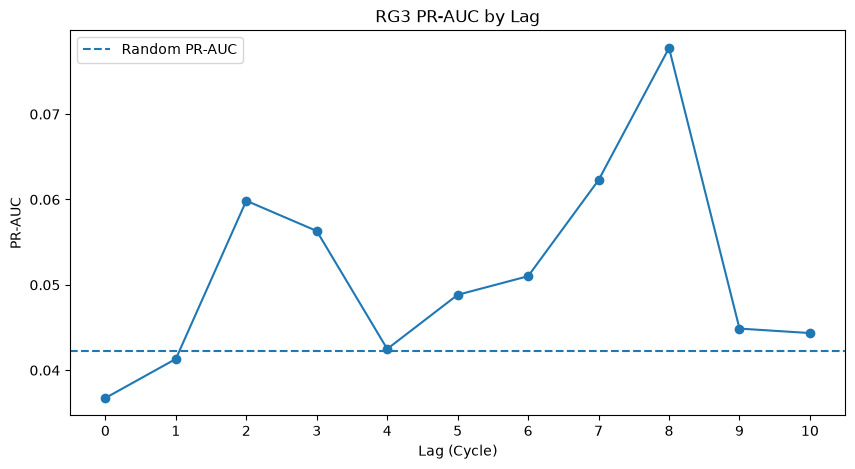

In [148]:
import matplotlib.pyplot as plt

plot_df = (
    lag_result_df
    .sort_values("Lag")
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    plot_df["Lag"],
    plot_df["PR_AUC"],
    marker="o"
)

plt.axhline(
    y=lag_analysis_df[
        "Cycle_Defect"
    ].mean(),
    linestyle="--",
    label="Random PR-AUC"
)

plt.xlabel("Lag (Cycle)")
plt.ylabel("PR-AUC")
plt.title(
    "RG3 PR-AUC by Lag"
)

plt.xticks(
    LAGS
)

plt.legend()
plt.show()

### Sensor Lag 분석

In [149]:
def evaluate_sensor_lag(
    df,
    sensor,
    lag
):
    feature = (
        f"{sensor}_lag{lag}"
    )

    X = df[
        [feature]
    ].copy()

    y = (
        df["Cycle_Defect"]
        .astype(int)
    )

    groups = df[
        "session_id"
    ]

    cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    oof_prob = np.zeros(
        len(df)
    )

    fold_pr = []
    fold_roc = []

    for train_idx, valid_idx in cv.split(
        X,
        y,
        groups=groups
    ):

        X_train = X.iloc[
            train_idx
        ]

        X_valid = X.iloc[
            valid_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        y_valid = y.iloc[
            valid_idx
        ]

        model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    C=0.5,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = (
            model
            .predict_proba(
                X_valid
            )[:, 1]
        )

        oof_prob[
            valid_idx
        ] = prob

        fold_pr.append(
            average_precision_score(
                y_valid,
                prob
            )
        )

        fold_roc.append(
            roc_auc_score(
                y_valid,
                prob
            )
        )

    return {
        "Sensor": sensor,
        "Lag": lag,

        "PR_AUC":
            average_precision_score(
                y,
                oof_prob
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                oof_prob
            ),

        "Fold_PR_Mean":
            np.mean(fold_pr),

        "Fold_PR_Min":
            np.min(fold_pr),

        "Fold_PR_Max":
            np.max(fold_pr)
    }

In [150]:
sensor_lag_results = []

for sensor in BASE_FEATURES:

    for lag in LAGS:

        result = (
            evaluate_sensor_lag(
                lag_analysis_df,
                sensor,
                lag
            )
        )

        sensor_lag_results.append(
            result
        )

### 가장 강한 Sensor Lag 조합

In [151]:
sensor_lag_df = (
    pd.DataFrame(
        sensor_lag_results
    )
    .sort_values(
        [
            "PR_AUC",
            "Fold_PR_Min"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    sensor_lag_df.head(30)
)

,Sensor,Lag,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Barrel_Temperature_5,3,0.091405,0.524048,0.116945,0.087484,0.167917
1,Hopper_Temperature,2,0.090166,0.543724,0.121503,0.057448,0.178906
2,Injection_Time,3,0.086795,0.523046,0.082735,0.039106,0.162433
3,Barrel_Temperature_6,4,0.085960,0.655265,0.106394,0.066180,0.176397
4,Barrel_Temperature_1,4,0.080290,0.609401,0.116678,0.083876,0.168140
5,Injection_Time,2,0.073731,0.502232,0.077046,0.043011,0.141460
6,Barrel_Temperature_5,0,0.072056,0.629486,0.097716,0.057613,0.133408
7,Barrel_Temperature_5,6,0.071633,0.594963,0.112802,0.053139,0.161715
8,Barrel_Temperature_6,10,0.071107,0.579340,0.088925,0.042042,0.146423
9,Max_Injection_Pressure,5,0.070906,0.584988,0.084634,0.057366,0.102975


In [153]:
best_lag_by_sensor = (
    sensor_lag_df
    .sort_values(
        [
            "PR_AUC",
            "Fold_PR_Min"
        ],
        ascending=False
    )
    .groupby(
        "Sensor",
        as_index=False
    )
    .first()
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    best_lag_by_sensor
)

,Sensor,Lag,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,Barrel_Temperature_5,3,0.091405,0.524048,0.116945,0.087484,0.167917
1,Hopper_Temperature,2,0.090166,0.543724,0.121503,0.057448,0.178906
2,Injection_Time,3,0.086795,0.523046,0.082735,0.039106,0.162433
3,Barrel_Temperature_6,4,0.085960,0.655265,0.106394,0.066180,0.176397
4,Barrel_Temperature_1,4,0.080290,0.609401,0.116678,0.083876,0.168140
5,Max_Injection_Pressure,5,0.070906,0.584988,0.084634,0.057366,0.102975
6,Max_Screw_RPM,6,0.070816,0.634952,0.076295,0.046381,0.101741
7,Barrel_Temperature_3,6,0.063241,0.613090,0.080820,0.049660,0.100119
8,Barrel_Temperature_2,10,0.061645,0.608763,0.122738,0.062317,0.210049
9,Cycle_Time,5,0.060440,0.537757,0.061007,0.044068,0.073422


In [154]:
best_sensor_by_lag = (
    sensor_lag_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .groupby(
        "Lag",
        as_index=False
    )
    .first()
    .sort_values("Lag")
)

display(
    best_sensor_by_lag
)

,Lag,Sensor,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
0,0,Barrel_Temperature_5,0.072056,0.629486,0.097716,0.057613,0.133408
1,1,Barrel_Temperature_3,0.062538,0.602933,0.065385,0.061266,0.071796
2,2,Hopper_Temperature,0.090166,0.543724,0.121503,0.057448,0.178906
3,3,Barrel_Temperature_5,0.091405,0.524048,0.116945,0.087484,0.167917
4,4,Barrel_Temperature_6,0.085960,0.655265,0.106394,0.066180,0.176397
5,5,Max_Injection_Pressure,0.070906,0.584988,0.084634,0.057366,0.102975
6,6,Barrel_Temperature_5,0.071633,0.594963,0.112802,0.053139,0.161715
7,7,Barrel_Temperature_1,0.069474,0.632310,0.083013,0.062820,0.112661
8,8,Barrel_Temperature_3,0.063185,0.601066,0.078424,0.057032,0.117327
9,9,Barrel_Temperature_5,0.063373,0.535936,0.086322,0.058697,0.101749


In [155]:
lag_heatmap_df = (
    sensor_lag_df
    .pivot(
        index="Sensor",
        columns="Lag",
        values="PR_AUC"
    )
)

display(
    lag_heatmap_df
)

Lag,0,1,2,3,4,5,6,7,8,9,10
Sensor,,,,,,,,,,,
Average_Back_Pressure,0.049849,0.038565,0.034511,0.044466,0.044671,0.058669,0.052080,0.046714,0.047720,0.039885,0.045418
Average_Screw_RPM,0.035219,0.036586,0.046608,0.035032,0.033844,0.043182,0.037646,0.043349,0.046905,0.038337,0.050370
Barrel_Temperature_1,0.030312,0.057839,0.053014,0.051507,0.080290,0.032270,0.042201,0.069474,0.054162,0.048451,0.055247
Barrel_Temperature_2,0.045115,0.048046,0.039042,0.054015,0.033600,0.037871,0.045013,0.044764,0.052205,0.044420,0.061645
Barrel_Temperature_3,0.042593,0.062538,0.041371,0.056303,0.041697,0.050771,0.063241,0.037638,0.063185,0.035544,0.031333
Barrel_Temperature_4,0.043401,0.049842,0.044104,0.036659,0.036568,0.037238,0.045678,0.054167,0.047949,0.036052,0.049178
Barrel_Temperature_5,0.072056,0.035859,0.039103,0.091405,0.039088,0.063981,0.071633,0.036648,0.039226,0.063373,0.034411
Barrel_Temperature_6,0.035079,0.038299,0.045214,0.032455,0.085960,0.044275,0.034817,0.031807,0.058635,0.037567,0.071107
Clamp_Close_Time,0.040707,0.037109,0.040899,0.040843,0.040843,0.044374,0.038374,0.038374,0.044476,0.041698,0.041754


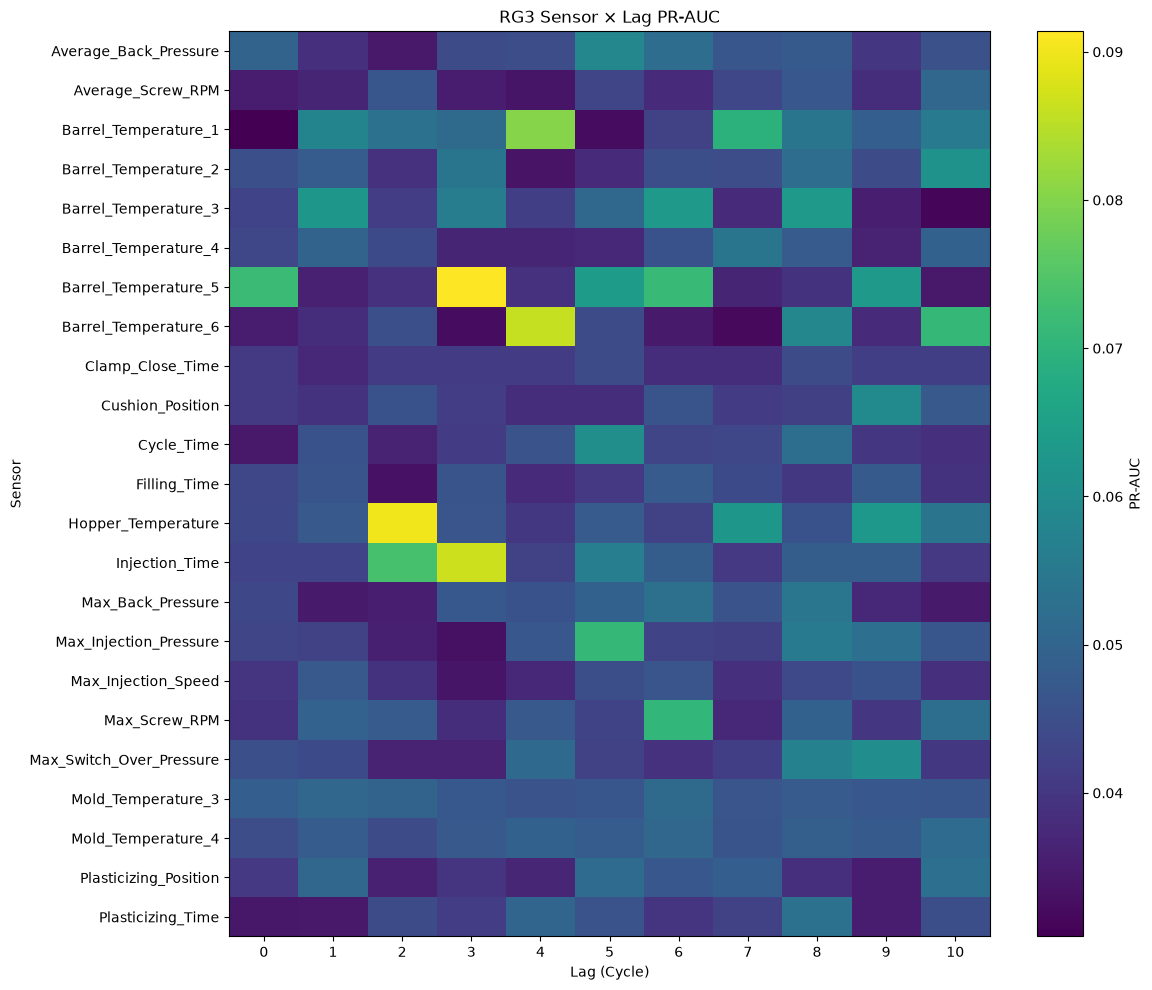

In [156]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12, 10)
)

plt.imshow(
    lag_heatmap_df.values,
    aspect="auto"
)

plt.colorbar(
    label="PR-AUC"
)

plt.xticks(
    range(len(lag_heatmap_df.columns)),
    lag_heatmap_df.columns
)

plt.yticks(
    range(len(lag_heatmap_df.index)),
    lag_heatmap_df.index
)

plt.xlabel(
    "Lag (Cycle)"
)

plt.ylabel(
    "Sensor"
)

plt.title(
    "RG3 Sensor × Lag PR-AUC"
)

plt.tight_layout()
plt.show()

In [157]:
FOCUS_SENSORS = [
    "Barrel_Temperature_5",
    "Cushion_Position",
    "Mold_Temperature_3"
]

focus_lag_df = (
    sensor_lag_df[
        sensor_lag_df[
            "Sensor"
        ].isin(
            FOCUS_SENSORS
        )
    ]
    .sort_values(
        [
            "Sensor",
            "Lag"
        ]
    )
)

display(
    focus_lag_df
)

,Sensor,Lag,PR_AUC,ROC_AUC,Fold_PR_Mean,Fold_PR_Min,Fold_PR_Max
6,Barrel_Temperature_5,0,0.072056,0.629486,0.097716,0.057613,0.133408
226,Barrel_Temperature_5,1,0.035859,0.383312,0.042469,0.033591,0.052161
190,Barrel_Temperature_5,2,0.039103,0.453999,0.052966,0.045079,0.068304
0,Barrel_Temperature_5,3,0.091405,0.524048,0.116945,0.087484,0.167917
191,Barrel_Temperature_5,4,0.039088,0.412826,0.057975,0.027153,0.103690
12,Barrel_Temperature_5,5,0.063981,0.616096,0.144215,0.053006,0.298269
7,Barrel_Temperature_5,6,0.071633,0.594963,0.112802,0.053139,0.161715
218,Barrel_Temperature_5,7,0.036648,0.397522,0.042105,0.036958,0.044733
186,Barrel_Temperature_5,8,0.039226,0.451357,0.043369,0.034551,0.049732
13,Barrel_Temperature_5,9,0.063373,0.535936,0.086322,0.058697,0.101749


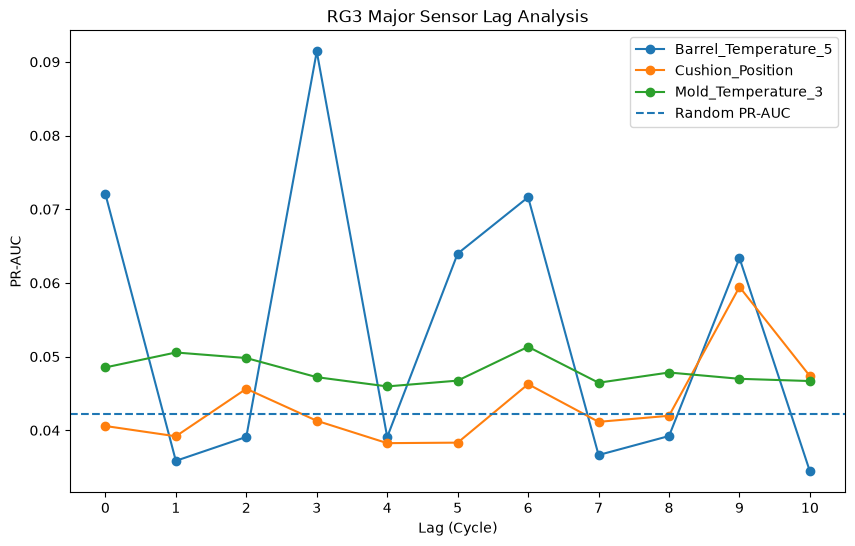

In [158]:
plt.figure(
    figsize=(10, 6)
)

for sensor in FOCUS_SENSORS:

    temp = (
        focus_lag_df[
            focus_lag_df[
                "Sensor"
            ] == sensor
        ]
        .sort_values("Lag")
    )

    plt.plot(
        temp["Lag"],
        temp["PR_AUC"],
        marker="o",
        label=sensor
    )

plt.axhline(
    y=lag_analysis_df[
        "Cycle_Defect"
    ].mean(),
    linestyle="--",
    label="Random PR-AUC"
)

plt.xlabel(
    "Lag (Cycle)"
)

plt.ylabel(
    "PR-AUC"
)

plt.title(
    "RG3 Major Sensor Lag Analysis"
)

plt.xticks(LAGS)
plt.legend()
plt.show()

# 5. 